# Análise Solar — Ciclos 23 e 24 (1997–2017)
Notebook que usa o pacote `Common` para rodar a CCF (manchas × X-ray) e o ajuste da lei de potência.

**Requisito de pasta:** este notebook deve estar na raiz do projeto (mesmo nível de `Common/`), com `dados/` e `gráficos/` também na raiz.

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import numpy as np

from Common.config import (
    SG_WINDOW, SG_POLYORDER, CAMINHO_MANCHAS, CAMINHO_XRAY,
    DIR_GRAFICOS, garantir_dir_graficos
)
from Common.dados import carregar_manchas_mensal, carregar_xray_mensal
from Common.processamento import suavizar, zscore_serie, preparar_xray_zscore_suave, alinhar
from Common.estatisticas import ccf_nanrob, ajustar_lei_potencia

garantir_dir_graficos()

## 1. Correlação Cruzada (CCF) — Manchas × X-ray

In [5]:
MAX_LAG = 12  # +-12 meses

manchas = carregar_manchas_mensal(CAMINHO_MANCHAS)
manchas_z = zscore_serie(manchas)
manchas_z_suave = suavizar(manchas_z, SG_WINDOW, SG_POLYORDER)

xray_mensal = carregar_xray_mensal(CAMINHO_XRAY)
xray_log_z, xray_suave = preparar_xray_zscore_suave(xray_mensal, SG_WINDOW, SG_POLYORDER)

common, (s_raw, x_raw) = alinhar(manchas_z, xray_log_z)
_, (s_suave, x_suave) = alinhar(manchas_z_suave, xray_suave)
N = len(common)

lags_r, corr_raw, ns_r = ccf_nanrob(s_raw, x_raw, MAX_LAG)
lags_s, corr_suave, ns_s = ccf_nanrob(s_suave, x_suave, MAX_LAG)

ci_r = 1.96 / np.sqrt(ns_r.mean())
ci_s = 1.96 / np.sqrt(ns_s.mean())

best_lag_raw = lags_r[np.nanargmax(np.abs(corr_raw))]
best_lag_suave = lags_s[np.nanargmax(np.abs(corr_suave))]
best_r_raw = corr_raw[np.nanargmax(np.abs(corr_raw))]
best_r_suave = corr_suave[np.nanargmax(np.abs(corr_suave))]

print(f"Lag ótimo (bruto) : {best_lag_raw:+d} meses  r = {best_r_raw:.3f}")
print(f"Lag ótimo (suave) : {best_lag_suave:+d} meses  r = {best_r_suave:.3f}")

Lag ótimo (bruto) : +0 meses  r = 0.769
Lag ótimo (suave) : +1 meses  r = 0.818


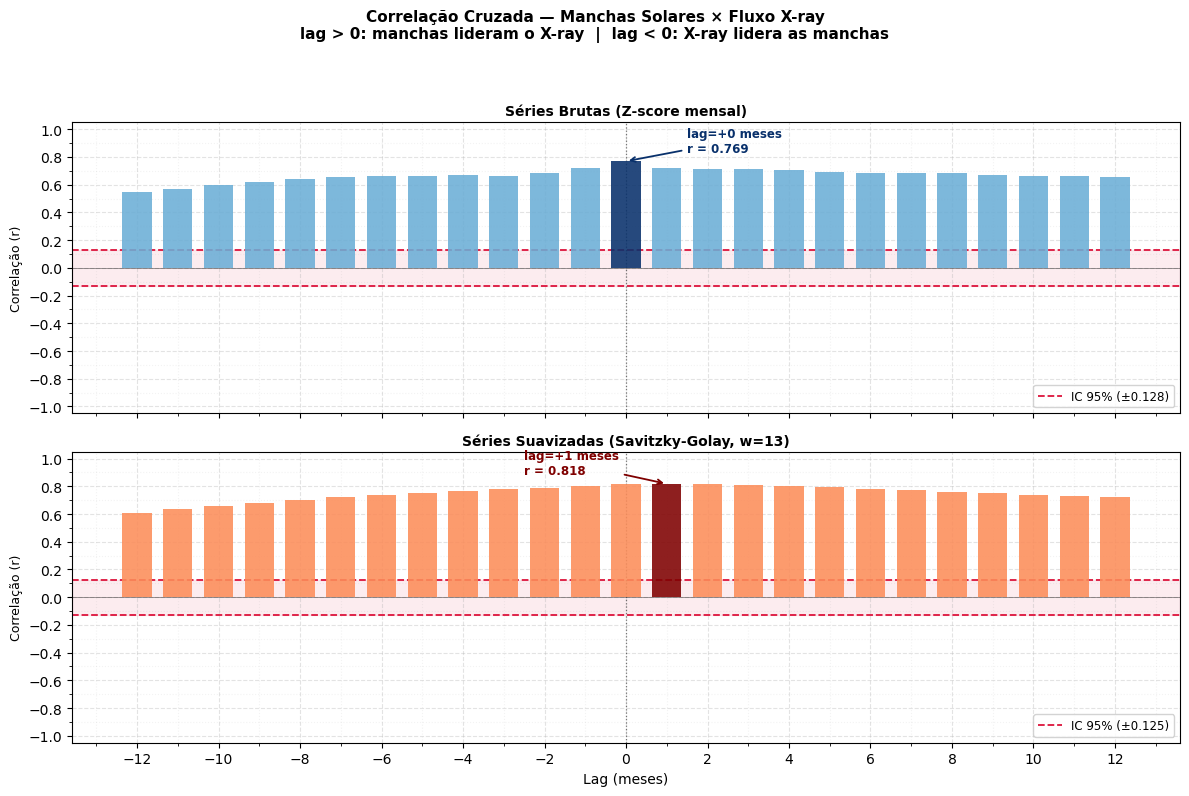

In [6]:
def plota_ccf(ax, lags, corrs, best_lag, best_r, ci, titulo, cor_bar, cor_dest):
    cores = [cor_dest if l == best_lag else cor_bar for l in lags]
    ax.bar(lags, corrs, color=cores, width=0.72, alpha=0.88, zorder=3)
    ax.axhspan(-ci, ci, color='crimson', alpha=0.08, zorder=1)
    ax.axhline(ci, color='crimson', linewidth=1.3, linestyle='--',
               label=f'IC 95% (±{ci:.3f})', zorder=2)
    ax.axhline(-ci, color='crimson', linewidth=1.3, linestyle='--', zorder=2)
    ax.axhline(0, color='black', linewidth=0.7, alpha=0.4, zorder=2)
    ax.axvline(0, color='black', linewidth=0.9, linestyle=':', alpha=0.5, zorder=2)
    h_off = 1.5 if best_lag <= 0 else -3.5
    v_off = 0.07 if best_r >= 0 else -0.10
    ax.annotate(
        f'lag={best_lag:+d} meses\nr = {best_r:.3f}',
        xy=(best_lag, best_r),
        xytext=(best_lag + h_off, best_r + v_off),
        fontsize=8.5, color=cor_dest, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=cor_dest, lw=1.3)
    )
    ax.set_title(titulo, fontsize=10, fontweight='bold', pad=5)
    ax.set_ylabel("Correlação (r)", fontsize=9)
    ax.set_ylim(-1.05, 1.05)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax.grid(True, which='major', linestyle='--', alpha=0.35)
    ax.grid(True, which='minor', linestyle=':', alpha=0.15)
    ax.legend(fontsize=8.5, loc='lower right', framealpha=0.85)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle(
    "Correlação Cruzada — Manchas Solares × Fluxo X-ray\n"
    "lag > 0: manchas lideram o X-ray  |  lag < 0: X-ray lidera as manchas",
    fontsize=11, fontweight='bold', y=0.99
)
plota_ccf(ax1, lags_r, corr_raw, best_lag_raw, best_r_raw, ci_r,
          "Séries Brutas (Z-score mensal)", '#6BAED6', '#08306B')
plota_ccf(ax2, lags_s, corr_suave, best_lag_suave, best_r_suave, ci_s,
          f"Séries Suavizadas (Savitzky-Golay, w={SG_WINDOW})", '#FC8D59', '#7F0000')
ax2.set_xlabel("Lag (meses)", fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f'{DIR_GRAFICOS}/ccf_manchas_xray.png', dpi=150)
plt.show()

## 2. Lei de Potência — X-ray × Manchas

In [7]:
manchas_sg = suavizar(manchas, SG_WINDOW, SG_POLYORDER)

xray_interp = xray_mensal.interpolate(method='time')
xray_sg = suavizar(xray_interp, SG_WINDOW, SG_POLYORDER)
xray_mensal_p = xray_mensal.copy()
xray_mensal_p.index = xray_mensal_p.index.to_period('M')
xray_sg.index = xray_sg.index.to_period('M')

common2, (manchas_c, manchas_sg_c, xray_c, xray_sg_c) = alinhar(
    manchas, manchas_sg, xray_mensal_p, xray_sg
)

manchas_v, manchas_sg_v = manchas_c.values, manchas_sg_c.values
xray_v, xray_sg_v = xray_c.values, xray_sg_c.values

mask_raw = (~np.isnan(manchas_v)) & (~np.isnan(xray_v)) & (manchas_v > 0) & (xray_v > 0)
mask_sg = (~np.isnan(manchas_sg_v)) & (~np.isnan(xray_sg_v)) & (manchas_sg_v > 0) & (xray_sg_v > 0)

m_r, x_r = manchas_v[mask_raw], xray_v[mask_raw]
m_s, x_s = manchas_sg_v[mask_sg], xray_sg_v[mask_sg]

β_r, a_r, r2_r, pv_r, ρ_r, res_r = ajustar_lei_potencia(m_r, x_r)
β_s, a_s, r2_s, pv_s, ρ_s, res_s = ajustar_lei_potencia(m_s, x_s)

print(f"[Bruto]  β={β_r:.3f}  log(a)={a_r:.3f}  R²={r2_r:.3f}  ρ={ρ_r:.3f}  p={pv_r:.1e}")
print(f"[SG]     β={β_s:.3f}  log(a)={a_s:.3f}  R²={r2_s:.3f}  ρ={ρ_s:.3f}  p={pv_s:.1e}")

[Bruto]  β=1.328  log(a)=-8.581  R²=0.838  ρ=0.879  p=1.3e-95
[SG]     β=1.365  log(a)=-8.571  R²=0.829  ρ=0.856  p=3.0e-94


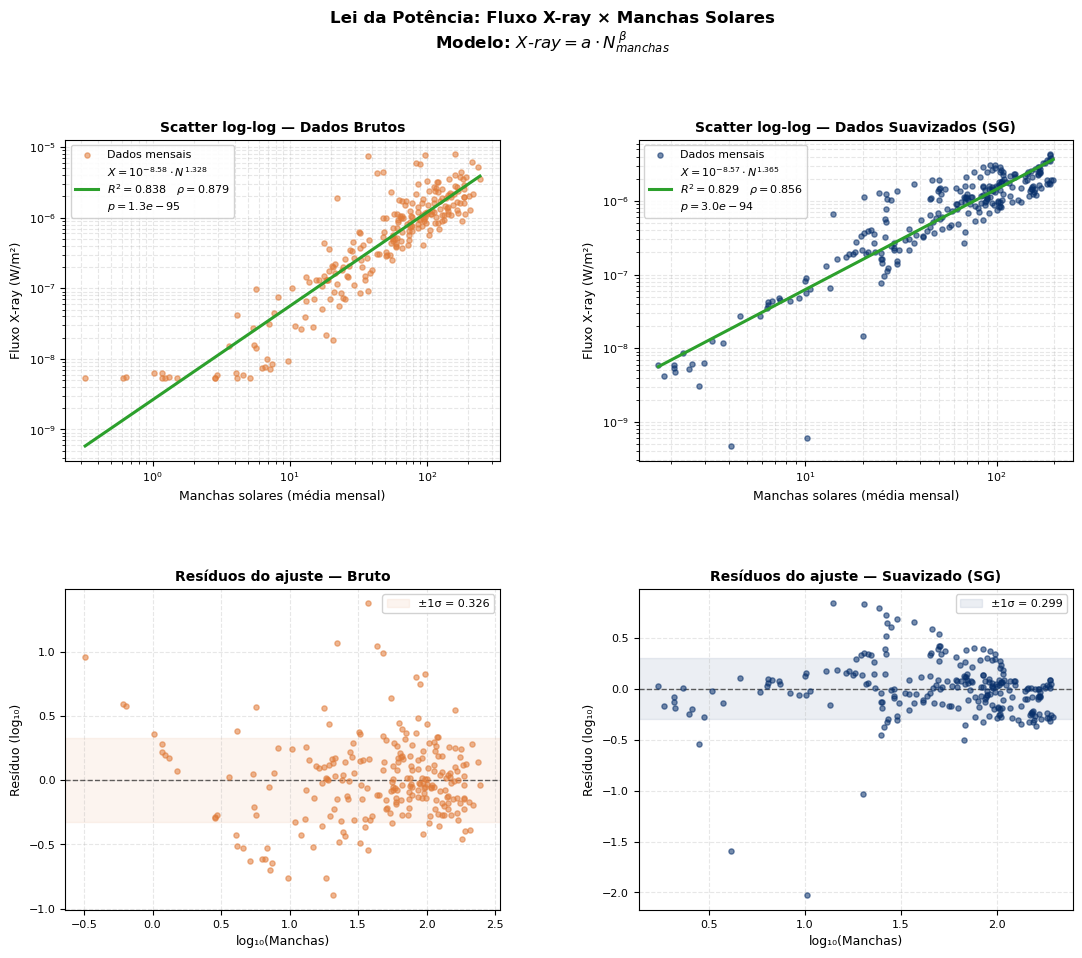

In [9]:
C_RAW = '#E07B39'
C_SG = '#08306B'
C_FIT = '#2CA02C'

def plota_scatter(ax, mx, xx, beta, a_ic, r2, pv, rho, cor, titulo):
    ax.scatter(mx, xx, s=14, alpha=0.55, color=cor, zorder=3, label='Dados mensais')
    xl = np.linspace(mx.min(), mx.max(), 300)
    yl = 10 ** (a_ic + beta * np.log10(xl))
    label_fit = (f'$X = 10^{{{a_ic:.2f}}} \\cdot N^{{{beta:.3f}}}$\n'
                 f'$R^2={r2:.3f}$   $\\rho={rho:.3f}$\n'
                 f'$p={pv:.1e}$')
    ax.plot(xl, yl, color=C_FIT, lw=2.2, zorder=4, label=label_fit)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Manchas solares (média mensal)', fontsize=9)
    ax.set_ylabel('Fluxo X-ray (W/m²)', fontsize=9)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.88, loc='upper left')
    ax.grid(True, which='both', linestyle='--', alpha=0.3)
    ax.tick_params(labelsize=8)

def plota_residuos(ax, mx, resid, cor, titulo):
    ax.scatter(np.log10(mx), resid, s=14, alpha=0.55, color=cor, zorder=3)
    ax.axhline(0, color='black', lw=1.0, linestyle='--', alpha=0.6)
    sigma = resid.std()
    ax.axhspan(-sigma, sigma, color=cor, alpha=0.08, label=f'±1σ = {sigma:.3f}')
    ax.set_xlabel('log₁₀(Manchas)', fontsize=9)
    ax.set_ylabel('Resíduo (log₁₀)', fontsize=9)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.88)
    ax.grid(True, which='major', linestyle='--', alpha=0.3)
    ax.tick_params(labelsize=8)

fig = plt.figure(figsize=(13, 10))
fig.suptitle(
    "Lei da Potência: Fluxo X-ray × Manchas Solares\n"
    r"Modelo: $X\text{-}ray = a \cdot N_{manchas}^{\,\beta}$",
    fontsize=12, fontweight='bold', y=1.01
)
gs = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.32)
ax_sc_r = fig.add_subplot(gs[0, 0])
ax_sc_s = fig.add_subplot(gs[0, 1])
ax_res_r = fig.add_subplot(gs[1, 0])
ax_res_s = fig.add_subplot(gs[1, 1])

plota_scatter(ax_sc_r, m_r, x_r, β_r, a_r, r2_r, pv_r, ρ_r, C_RAW, "Scatter log-log — Dados Brutos")
plota_scatter(ax_sc_s, m_s, x_s, β_s, a_s, r2_s, pv_s, ρ_s, C_SG, "Scatter log-log — Dados Suavizados (SG)")
plota_residuos(ax_res_r, m_r, res_r, C_RAW, "Resíduos do ajuste — Bruto")
plota_residuos(ax_res_s, m_s, res_s, C_SG, "Resíduos do ajuste — Suavizado (SG)")

fig.savefig(f'{DIR_GRAFICOS}/lei_potencia_xray_manchas.png', dpi=150, bbox_inches='tight')
plt.show()